### Time_Series_Forecast_Selective_Reporting

Shows how selective reporting can make model seem to be better

In [3]:
import os, sys, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

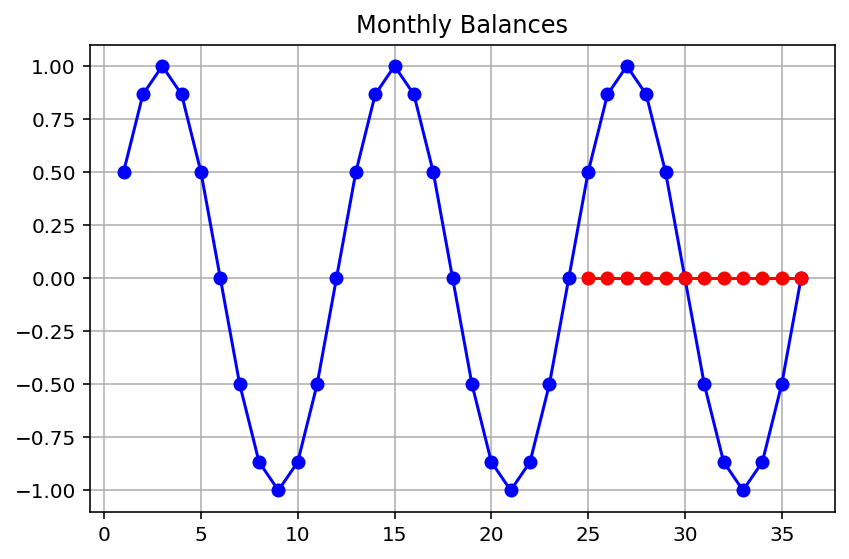

In [4]:
# suppose we have actual values for 3 years (36 months)
months = np.arange(1, 37, 1)
vals   = np.sin(months*2*math.pi/12.0)

# Suppose that we use first 24 months 
# to train a simple forecasting model.
# It is so trivial - it predicts zero values.

months_pred = np.arange(25, 37, 1)
vals_pred   = np.full(12,0)         # 12 points with 0 values 

fig, ax = plt.subplots(figsize=(6,4))
_ = ax.plot(months, vals, color="blue", marker='o')
_ = ax.plot(months_pred, vals_pred, color="red", marker='o')
_ = ax.set_title(f"Monthly Balances")
_ = ax.grid(True)

fig.tight_layout()
plt.show() ; # semicolon needed to remove text output on top

In [5]:
print(vals[24:].shape)
print(vals_pred.shape)

(12,)
(12,)


In [8]:
# Let's calculate the WAPE of the prediction
# https://www.baeldung.com/cs/mape-vs-wape-vs-wmape

def wape (actual, predicted):
    Na = len(actual)
    Np = len(predicted)
    if Na == 0 or Np == 0 or Na != Np:
        return np.nan
    denom = np.absolute(actual).sum()
    if denom <= 0:
        return np.nan
    nomin = np.absolute(actual - predicted).sum()
    return (nomin / denom) / Na

# test
# print(wape(np.array([1,2,3]),np.array([1,2,3])))
# print(wape(np.array([1,2,3]),np.array([1,2,2])))
# print(wape(np.array([0,0,0]),np.array([1,2,2])))

In [9]:
print(wape(vals[24:], vals[24:]))
print(wape(vals[24:], vals_pred))

0.0
0.08333333333333333


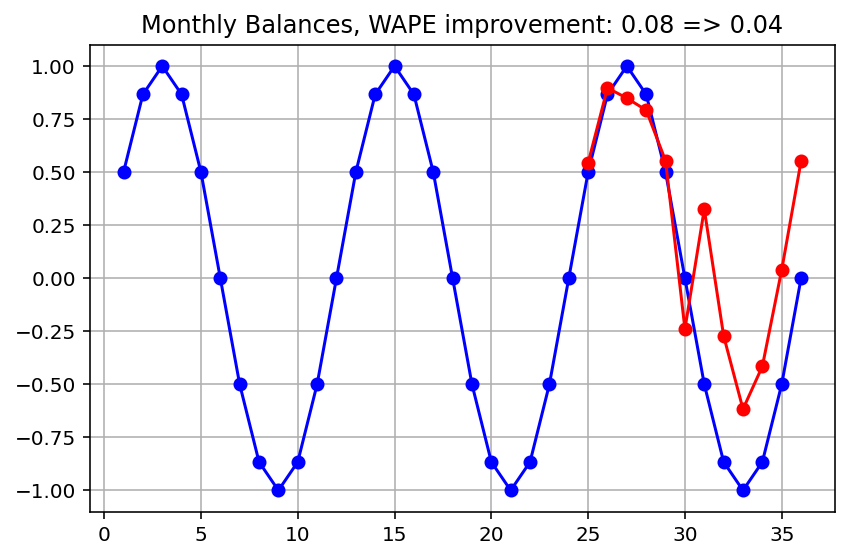

In [10]:
# Now let's try to improve prediction by using randomness

wape_best = wape(vals[24:], vals_pred)
wape_best_orig = wape_best
vals_best = np.full(12,0) 

N = 1000
for counter in range(N):
    vals_temp = 1.8*(np.random.rand(12) - 0.5)
    wape_temp = wape(vals[24:], vals_temp)
    if wape_temp < wape_best:
        wape_best = wape_temp
        vals_best = vals_temp

# print(f"WAPE improvement: {wape_best_orig} => {wape_best}")
fig, ax = plt.subplots(figsize=(6,4))
_ = ax.plot(months, vals, color="blue", marker='o')
_ = ax.plot(months_pred, vals_best, color="red", marker='o')
_ = ax.set_title(f"Monthly Balances, "+f"WAPE improvement: {wape_best_orig:.2f} => {wape_best:.2f}")
_ = ax.grid(True)

fig.tight_layout()
plt.show() ; # semicolon needed to remove text output on top